In [1]:
import pandas as pd

In [2]:
teams = pd.read_csv('teams.csv')

In [3]:
teams

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,19,26,25.0,179.0,71.1,0,0.0,0.0
2140,ZIM,Zimbabwe,2004,11,14,25.1,177.8,70.5,3,0.0,0.0
2141,ZIM,Zimbabwe,2008,15,16,26.1,171.9,63.7,4,3.0,1.0
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3


In [4]:
teams = teams[['team','country','year','athletes','age','prev_medals','medals']]

In [5]:
teams

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0.0,0
2140,ZIM,Zimbabwe,2004,14,25.1,0.0,3
2141,ZIM,Zimbabwe,2008,16,26.1,3.0,4
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0


In [7]:
teams.corr(numeric_only = True)['medals']

year          -0.021603
athletes       0.840817
age            0.025096
prev_medals    0.920048
medals         1.000000
Name: medals, dtype: float64

In [8]:
import seaborn as sns

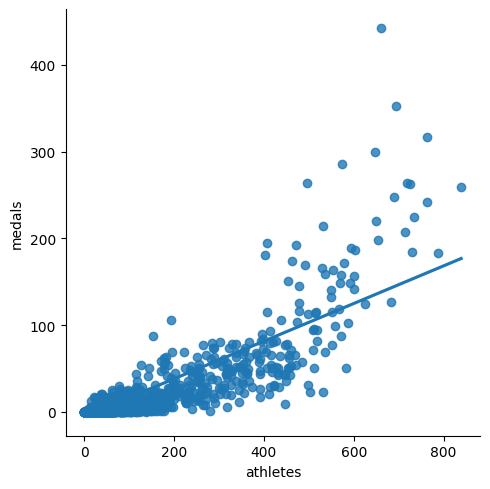

In [12]:
sns.lmplot(teams,x='athletes', y='medals',fit_reg=True,ci=None)

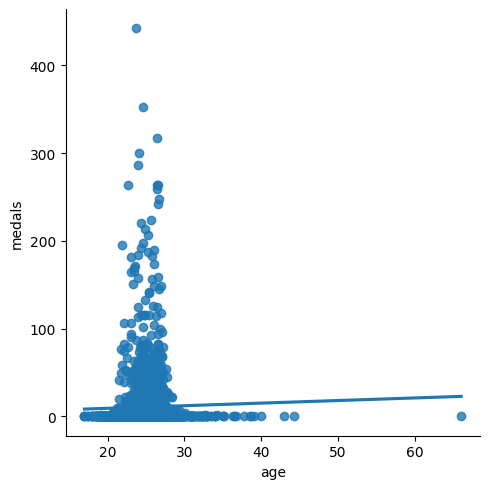

In [13]:
sns.lmplot(teams,x='age', y='medals',fit_reg=True,ci=None)

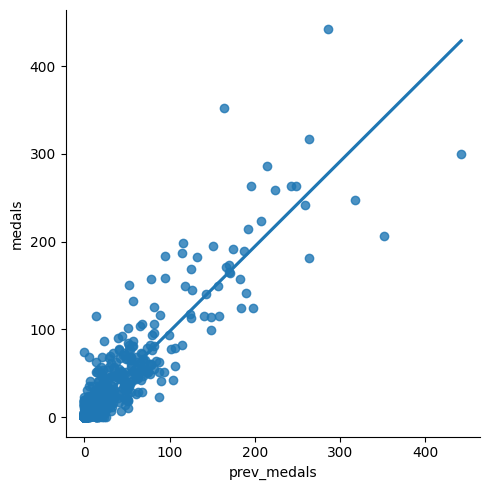

In [14]:
sns.lmplot(teams,x='prev_medals', y='medals',fit_reg=True,ci=None)

<Axes: ylabel='Frequency'>

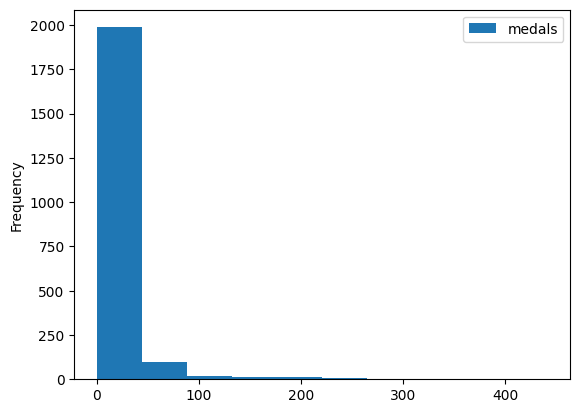

In [15]:
teams.plot.hist(y='medals')


In [16]:
teams.isnull().sum()

team             0
country          0
year             0
athletes         0
age              0
prev_medals    130
medals           0
dtype: int64

In [17]:
teams = teams.dropna()

In [18]:
teams

,team,country,year,athletes,age,prev_medals,medals
0,AFG,Afghanistan,1964,8,22.0,0.0,0
1,AFG,Afghanistan,1968,5,23.2,0.0,0
2,AFG,Afghanistan,1972,8,29.0,0.0,0
3,AFG,Afghanistan,1980,11,23.6,0.0,0
4,AFG,Afghanistan,2004,5,18.6,0.0,0
...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,26,25.0,0.0,0
2140,ZIM,Zimbabwe,2004,14,25.1,0.0,3
2141,ZIM,Zimbabwe,2008,16,26.1,3.0,4
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0


In [41]:
train = teams[teams['year'] < 2012].copy()
test =  teams[teams['year'] >= 2012].copy()

In [42]:
from sklearn.linear_model import LinearRegression

In [46]:
reg = LinearRegression()

In [47]:
predictors = ['athletes','prev_medals']
target = ['medals']

In [48]:
reg.fit(train[predictors],train['medals'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.07,0.75]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['athletes','prev_medals']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.142
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [49]:
predictions = reg.predict(test[predictors])

In [50]:
predictions

array([-9.61221245e-01, -1.17633261e+00, -1.42503158e+00, -1.71184673e+00,
        2.15562926e+00,  3.91463636e+00, -1.71184673e+00, -1.85525431e+00,
        3.67563128e-01, -2.77770967e-01, -1.85525431e+00, -1.49673537e+00,
        4.67519911e+01,  2.87550937e+01,  4.58450091e+00,  2.54773581e+00,
       -1.85525431e+00, -1.64014295e+00, -1.85525431e+00, -1.85525431e+00,
        1.46556876e+02,  1.20571799e+02,  6.56314795e+00,  3.95275254e+00,
        7.34283247e+00,  1.03117468e+01,  5.19171882e+00,  3.58517645e+00,
       -1.64014295e+00, -1.64014295e+00, -1.56843916e+00, -1.20992022e+00,
       -1.71184673e+00, -1.42503158e+00,  1.17929959e+01,  1.00049298e+01,
       -1.78355052e+00, -1.71184673e+00, -1.56843916e+00, -1.56843916e+00,
       -1.99866189e+00, -1.99866189e+00, -1.56843916e+00, -1.35332779e+00,
       -1.92695810e+00, -1.92695810e+00,  3.28912706e+01,  2.53042547e+01,
       -1.78355052e+00, -1.28162400e+00, -1.85525431e+00, -3.87590939e-01,
        7.83480779e+01,  

In [51]:
    test['predictions'] = predictions

In [52]:
test

,team,country,year,athletes,age,prev_medals,medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,-0.961221
7,AFG,Afghanistan,2016,3,24.7,1.0,0,-1.176333
24,ALB,Albania,2012,10,25.7,0.0,0,-1.425032
25,ALB,Albania,2016,6,23.7,0.0,0,-1.711847
37,ALG,Algeria,2012,39,24.8,2.0,1,2.155629
...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,19.3,0.0,0,-1.926958
2131,ZAM,Zambia,2012,7,22.6,0.0,0,-1.640143
2132,ZAM,Zambia,2016,7,24.1,0.0,0,-1.640143
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0,1.505767


In [53]:
test.loc[test['predictions'] < 0,'predictions'] = 0

In [54]:
test['predictions'] =test['predictions'].round()

In [55]:
test

,team,country,year,athletes,age,prev_medals,medals,predictions
6,AFG,Afghanistan,2012,6,24.8,1.0,1,0.0
7,AFG,Afghanistan,2016,3,24.7,1.0,0,0.0
24,ALB,Albania,2012,10,25.7,0.0,0,0.0
25,ALB,Albania,2016,6,23.7,0.0,0,0.0
37,ALG,Algeria,2012,39,24.8,2.0,1,2.0
...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,19.3,0.0,0,0.0
2131,ZAM,Zambia,2012,7,22.6,0.0,0,0.0
2132,ZAM,Zambia,2016,7,24.1,0.0,0,0.0
2142,ZIM,Zimbabwe,2012,9,27.3,4.0,0,2.0


In [56]:
from sklearn.metrics import mean_absolute_error

In [57]:
error = mean_absolute_error(test['medals'],test['predictions'])

In [58]:
error

3.2987654320987656

In [59]:
teams.describe()['medals']

count    2014.000000
mean       10.990070
std        33.627528
min         0.000000
25%         0.000000
50%         0.000000
75%         5.000000
max       442.000000
Name: medals, dtype: float64

In [60]:
test[test['team'] == 'USA']

,team,country,year,athletes,age,prev_medals,medals,predictions
2053,USA,United States,2012,689,26.7,317.0,248,285.0
2054,USA,United States,2016,719,26.4,248.0,264,236.0


In [61]:
test[test['team'] == 'IND']

,team,country,year,athletes,age,prev_medals,medals,predictions
907,IND,India,2012,95,26.0,3.0,6,7.0
908,IND,India,2016,130,26.1,6.0,2,12.0


In [66]:
errors = (test['medals'] - test['predictions']).abs()

In [67]:
errors

6       1.0
7       0.0
24      0.0
25      0.0
37      1.0
       ... 
2111    0.0
2131    0.0
2132    0.0
2142    2.0
2143    0.0
Length: 405, dtype: float64

In [86]:
error_by_team = errors.groupby(test['team']).mean()

In [87]:
error_by_team

team
AFG    0.5
ALB    0.0
ALG    1.5
AND    0.0
ANG    0.0
      ... 
VIE    1.0
VIN    0.0
YEM    0.0
ZAM    0.0
ZIM    1.0
Length: 204, dtype: float64

In [88]:
medals_by_team = test['medals'].groupby(test['team']).mean()

In [89]:
error_ratio = error_by_team / medals_by_team

In [90]:
error_ratio

team
AFG    1.0
ALB    NaN
ALG    1.0
AND    NaN
ANG    NaN
      ... 
VIE    1.0
VIN    NaN
YEM    NaN
ZAM    NaN
ZIM    inf
Length: 204, dtype: float64

In [91]:
error_ratio[~pd.isnull(error_ratio)]

team
AFG    1.000000
ALG    1.000000
ARG    0.853659
ARM    0.428571
AUS    0.367347
         ...   
USA    0.126953
UZB    0.625000
VEN    1.750000
VIE    1.000000
ZIM         inf
Length: 102, dtype: float64

In [92]:
error_ratio = error_ratio[np.isfinite(error_ratio)]

In [93]:
error_ratio

team
AFG    1.000000
ALG    1.000000
ARG    0.853659
ARM    0.428571
AUS    0.367347
         ...   
UKR    0.951220
USA    0.126953
UZB    0.625000
VEN    1.750000
VIE    1.000000
Length: 97, dtype: float64

<Axes: ylabel='Frequency'>

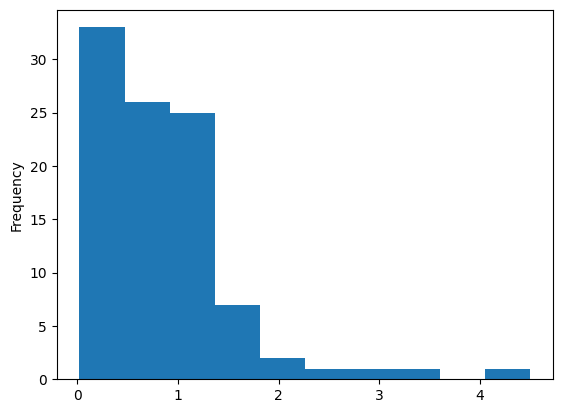

In [94]:
error_ratio.plot.hist()

In [96]:
error_ratio.sort_values()

team
FRA    0.022472
CAN    0.048387
NZL    0.063492
RUS    0.082353
ITA    0.121429
         ...   
MAR    2.000000
EGY    2.400000
HKG    3.000000
POR    3.333333
AUT    4.500000
Length: 97, dtype: float64

In [97]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# 1. Define predictors and target
predictors = ['athletes', 'prev_medals']
target = 'medals'

X_train = train[predictors]
y_train = train[target]
X_test = test[predictors]
y_test = test[target]

# 2. Scale the features (Crucial for SVM and KNN to perform well)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Helper function to train, predict, clip negatives, and evaluate
def train_and_evaluate(model, X_tr, X_te, y_tr, y_te, model_name):
    # Train the model
    model.fit(X_tr, y_tr)
    
    # Make predictions
    preds = model.predict(X_te)
    
    # Clip negative predictions to 0 (a country can't win negative medals)
    preds = np.maximum(0, preds)
    
    # Calculate Mean Absolute Error
    mae = mean_absolute_error(y_te, preds)
    print(f"{model_name} Mean Absolute Error (MAE): {mae:.4f}")
    
    return preds, mae

print("Training models...\n" + "-"*40)

# 3. Train XGBoost Regressor
# Note: XGBoost handles unscaled data well, but we can pass the unscaled version
xgb_model = XGBRegressor(random_state=42, n_estimators=100)
xgb_preds, xgb_mae = train_and_evaluate(xgb_model, X_train, X_test, y_train, y_test, "XGBoost")

# 4. Train Support Vector Regression (SVR)
svm_model = SVR()
svm_preds, svm_mae = train_and_evaluate(svm_model, X_train_scaled, X_test_scaled, y_train, y_test, "SVM (SVR)")

# 5. Train K-Nearest Neighbors Regressor (KNN)
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_preds, knn_mae = train_and_evaluate(knn_model, X_train_scaled, X_test_scaled, y_train, y_test, "KNN")

# 6. Summary Comparison
print("\n" + "="*40)
print("MODEL PERFORMANCE SUMMARY (Lower MAE is better)")
print("="*40)
print(f"XGBoost MAE: {xgb_mae:.4f}")
print(f"SVM MAE:     {svm_mae:.4f}")
print(f"KNN MAE:     {knn_mae:.4f}")

Training models...
----------------------------------------


XGBoost Mean Absolute Error (MAE): 4.0921
SVM (SVR) Mean Absolute Error (MAE): 5.2247
KNN Mean Absolute Error (MAE): 3.5570

MODEL PERFORMANCE SUMMARY (Lower MAE is better)
XGBoost MAE: 4.0921
SVM MAE:     5.2247
KNN MAE:     3.5570


In [100]:
import joblib

# Save the models
joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(reg, 'linear_model.pkl')
joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(knn_model, 'knn_model.pkl')

# Save the scaler (crucial for SVM and KNN)
joblib.dump(scaler, 'scaler.pkl')

print("Models and scaler saved successfully!")

Models and scaler saved successfully!
